# EduStress AI: Classificação e Identificação de Fatores de Estresse em Estudantes com Aprendizado de Máquina

Este notebook apresenta um fluxo completo de **Machine Learning supervisionado** para classificar o nível de estresse de estudantes (`stress_level`) a partir de fatores psicológicos, fisiológicos, ambientais, acadêmicos e sociais.

Além da avaliação do modelo, o notebook também analisa a **importância das características (features)** para ajudar a identificar quais fatores têm maior contribuição para as previsões do modelo.


In [1]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print('Bibliotecas importadas com sucesso!')


Bibliotecas importadas com sucesso!


## 1. Carregamento e exploração dos dados

O dataset fica em `data/StressLevelDataset.csv`. O código abaixo procura o arquivo localmente (execução a partir da pasta `notebooks/` ou da raiz do repositório) e, se não encontrar — como ao abrir o notebook direto no Google Colab —, carrega a cópia publicada no GitHub. Em seguida, verifica as dimensões, apresenta as primeiras linhas e confere valores ausentes.

In [2]:
# Carregando o dataset
from pathlib import Path

DATA_URL = 'https://raw.githubusercontent.com/rayanelbarbosa/EduStress_AI/main/data/StressLevelDataset.csv'
candidatos = [
    Path('../data/StressLevelDataset.csv'),  # executando a partir de notebooks/
    Path('data/StressLevelDataset.csv'),     # executando a partir da raiz do repositório
    Path('StressLevelDataset.csv'),          # arquivo enviado manualmente ao Colab
]
fonte = next((str(c) for c in candidatos if c.exists()), DATA_URL)
df = pd.read_csv(fonte)

print(f'Dataset carregado de: {fonte}')
print(f'Dimensões do dataset: {df.shape}')
display(df.head())

print('\nTipos de dados:')
print(df.dtypes)

print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

Dataset carregado de: ../data/StressLevelDataset.csv
Dimensões do dataset: (1100, 21)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1



Tipos de dados:
anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

Total de valores nulos: 0


Distribuição da variável alvo (stress_level):
stress_level
0    373
1    358
2    369
Name: count, dtype: int64


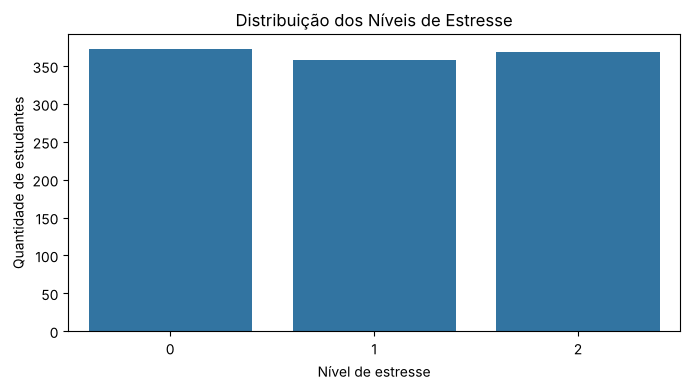

In [3]:
# Verificando a distribuição da variável alvo
if 'stress_level' not in df.columns:
    raise ValueError("A coluna alvo 'stress_level' não foi encontrada no dataset.")

print('Distribuição da variável alvo (stress_level):')
print(df['stress_level'].value_counts().sort_index())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='stress_level')
plt.title('Distribuição dos Níveis de Estresse')
plt.xlabel('Nível de estresse')
plt.ylabel('Quantidade de estudantes')
plt.tight_layout()
plt.show()


## 2. Preparação dos dados

A variável `stress_level` será utilizada como **target (y)**, enquanto as demais colunas serão utilizadas como **features (X)**.

A divisão em treino e teste utiliza estratificação para preservar, tanto quanto possível, a proporção das classes nos dois conjuntos.


In [4]:
X = df.drop(columns=['stress_level'])
y = df['stress_level']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Tamanho do conjunto de treino: {X_train.shape[0]} amostras')
print(f'Tamanho do conjunto de teste: {X_test.shape[0]} amostras')


Tamanho do conjunto de treino: 880 amostras
Tamanho do conjunto de teste: 220 amostras


## 3. Construção do modelo e otimização de hiperparâmetros

Será utilizado o algoritmo **Random Forest Classifier**, adequado para classificação tabular e capaz de fornecer uma medida de importância das características.

Diferentemente de modelos como KNN, SVM ou regressão logística, o Random Forest **não exige padronização das variáveis**. Por isso, o `StandardScaler` foi removido para manter o pipeline mais simples e coerente com o algoritmo escolhido.

O `GridSearchCV` testa diferentes combinações de hiperparâmetros utilizando validação cruzada estratificada, sem utilizar o conjunto de teste durante a otimização.


In [5]:
# Pipeline contendo apenas o classificador
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

# Grade de hiperparâmetros
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print('Treinando o modelo com GridSearchCV...')
grid_search.fit(X_train, y_train)

print('\nMelhores parâmetros encontrados:')
print(grid_search.best_params_)

print(f'\nMelhor acurácia média na validação cruzada: {grid_search.best_score_:.4f}')


Treinando o modelo com GridSearchCV...



Melhores parâmetros encontrados:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Melhor acurácia média na validação cruzada: 0.8807


## 4. Avaliação do modelo no conjunto de teste

O melhor modelo encontrado na validação cruzada será avaliado no conjunto de teste, que permaneceu separado durante todo o processo de otimização.


In [6]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f'Acurácia no conjunto de teste: {accuracy:.4f}\n')
print('Relatório de classificação:')
print(classification_report(y_test, y_pred, zero_division=0))


Acurácia no conjunto de teste: 0.8864

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        74
           1       0.87      0.93      0.90        72
           2       0.87      0.91      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



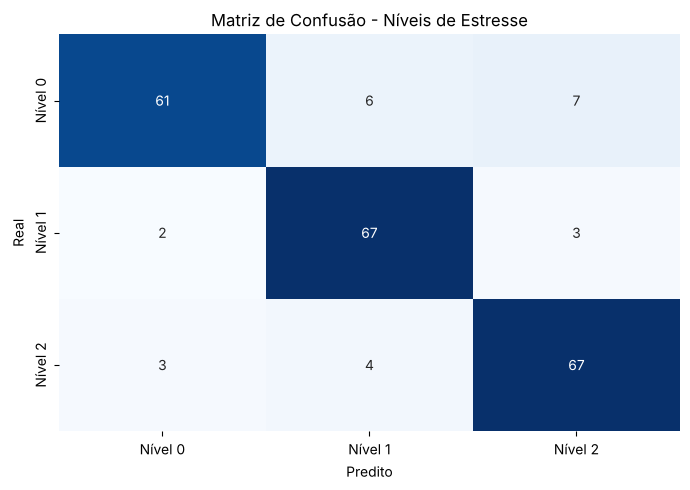

In [7]:
# Matriz de confusão
labels = np.sort(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=[f'Nível {label}' for label in labels],
    yticklabels=[f'Nível {label}' for label in labels]
)
plt.title('Matriz de Confusão - Níveis de Estresse')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()


## 5. Identificação dos fatores mais relevantes

O Random Forest permite consultar a importância de cada feature no processo de decisão das árvores. Essa análise ajuda a responder à segunda parte da proposta do projeto: **identificar os fatores mais relevantes para as previsões de estresse**.

> Importante: importância de feature indica relevância para a previsão do modelo. Ela **não prova causalidade** nem significa, por si só, que determinado fator seja a causa do estresse.


Fatores mais relevantes para o modelo:


,importance
blood_pressure,0.146809
sleep_quality,0.080136
teacher_student_relationship,0.071204
basic_needs,0.066201
academic_performance,0.065007
depression,0.064697
self_esteem,0.063387
social_support,0.058739
anxiety_level,0.058509
bullying,0.050541


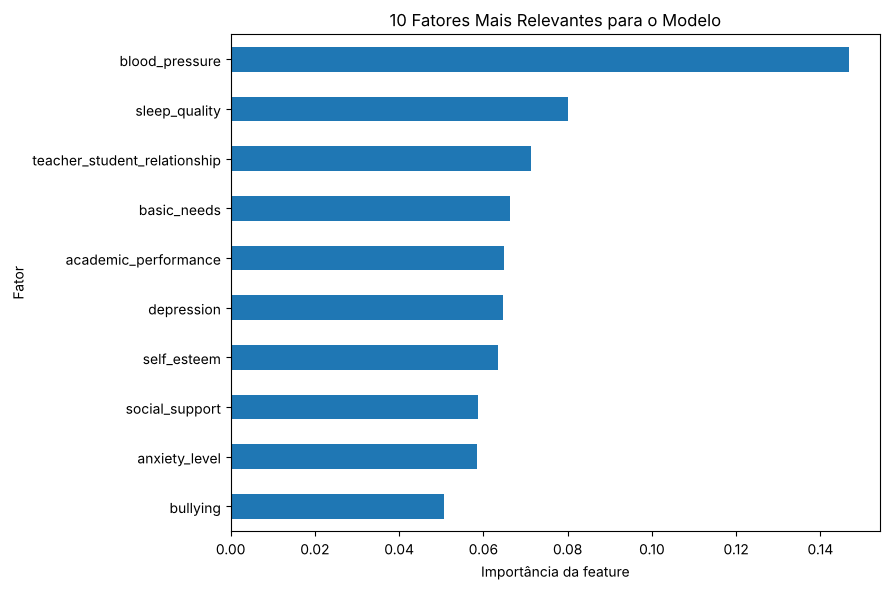

In [8]:
# Extraindo as importâncias das features do Random Forest
rf_model = best_model.named_steps['classifier']

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print('Fatores mais relevantes para o modelo:')
display(feature_importance.to_frame('importance'))

# Visualização das 10 features mais importantes
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))
top_features.plot(kind='barh')
plt.title('10 Fatores Mais Relevantes para o Modelo')
plt.xlabel('Importância da feature')
plt.ylabel('Fator')
plt.tight_layout()
plt.show()


## 6. Conclusão

Ao final da execução, este notebook fornece:

- a preparação e divisão dos dados;
- um modelo Random Forest otimizado por validação cruzada;
- a acurácia e o relatório de classificação no conjunto de teste;
- a matriz de confusão para análise dos erros;
- a lista e a visualização dos fatores mais relevantes para as previsões.

Os resultados obtidos devem ser interpretados considerando as características, limitações e origem do dataset utilizado. As importâncias das features representam associações com o comportamento do modelo e não devem ser interpretadas automaticamente como relações de causa e efeito.
